# `Материалы кафедры ММП факультета ВМК МГУ. Введение в глубокое обучение.`

# `Занятие 21. Как обучать LLM?`

## `Занятие провел: Марьясов Максим (@oop_clon)`

## `Материалы составил: Марьясов Максим (@oop_clon)`


### `Москва, Весенний семестр 2026`

Источники:
-  **Language Models are Few-Shot Learners**: [Tom B. Brown et al., 2020](https://arxiv.org/abs/2005.14165), примерно 70,000 цитирований &ndash; статья про GPT-3, где показано, что масштабирование моделей приводит к появлению in-context learning и позволяет решать задачи без fine-tuning  

- **Language Models are Unsupervised Multitask Learners (GPT-2)**: [Alec Radford et al., 2019](https://openai.com/research/better-language-models), примерно 24,000 цитирований &ndash; демонстрация того, что крупные языковые модели могут решать множество задач в zero-shot режиме без явного обучения на них  

- **Training language models to follow instructions with human feedback (InstructGPT)**: [Long Ouyang et al., 2022](https://arxiv.org/abs/2203.02155), примерно 24,000 цитирований &ndash; формализация RLHF-пайплайна: SFT → reward model → PPO для выравнивания модели с человеческими предпочтениями  

- **Deep Reinforcement Learning from Human Preferences**: [Paul Christiano et al., 2017](https://arxiv.org/abs/1706.03741), примерно 7,000 цитирований &ndash; базовый подход к обучению через человеческие предпочтения, лежащий в основе RLHF  

- **Direct Preference Optimization (DPO)**: [Rafael Rafailov et al., 2023](https://arxiv.org/abs/2305.18290), примерно 8,500 цитирований &ndash; альтернатива RLHF без отдельной reward-модели и RL, сводящая обучение к прямой оптимизации предпочтений

Цель данного семинара &ndash; воспроизвести упрощённый, но концептуально полный пайплайн обучения современных языковых моделей.

Мы последовательно рассмотрим три этапа:
1. Базовая языковая модель (pre-training LM), обученная на задаче next-token prediction;
2. Supervised Fine-Tuning (SFT), в котором модель адаптируется к формату "инструкция → ответ";
3. Direct Preference Optimization (DPO), где модель обучается учитывать относительные предпочтения между ответами.

Главное, что наа всех этапах архитектура модели остаётся неизменной, изменяются только данные и функция потерь.

---

In [1]:
import torch
import torch.nn.functional as F
from torch.utils.data import DataLoader
from transformers import AutoTokenizer, AutoModelForCausalLM
from datasets import load_dataset
import matplotlib.pyplot as plt
import numpy as np
from tqdm.auto import tqdm
import copy
import gc
import re

## Подготовка данных

In [2]:
!pip install -q transformers datasets torch trl accelerate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 721.6/721.6 kB 22.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 529.0/529.0 kB 49.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.9/48.9 MB 20.2 MB/s eta 0:00:00


В качестве предобученной модели для сегодняшнего семинара была выбрана GPT2 - [Language Models are Unsupervised Multitask Learners (GPT-2)](https://openai.com/research/better-language-models) ~24,000 цитирований от OpenAI.

In [3]:

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

model_name = "gpt2"
tokenizer = AutoTokenizer.from_pretrained(model_name)
tokenizer.pad_token = tokenizer.eos_token

# Для обучения causal LM удобнее right padding:
# тогда промпт, ответ и labels находятся в одних и тех же позициях.
# Left padding часто используют только для batched generation.
tokenizer.padding_side = "right"

model = AutoModelForCausalLM.from_pretrained(model_name).to(device)
print(f"Модель: {model_name}, параметров: "
      f"{sum(p.numel() for p in model.parameters()):,}")


Device: cuda


config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

...

model.safetensors:   0%|          | 0.00/548M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: gpt2
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

Модель: gpt2, параметров: 124,439,808


Рассматриваемая модель является стандартной авторегрессионной языковой моделью, обученной максимизировать правдоподобие последовательности:

$$log P(x_1, …, x_T) = \sum_t log P(x_t | x_{<t}).$$

Такая постановка не предполагает наличия "задачи" в явном виде: модель обучается аппроксимировать распределение естественного языка.

Следовательно, при подаче вопроса модель не обязана давать ответ &ndash; она лишь продолжает наблюдаемую текстовую последовательность наиболее вероятным образом.

In [4]:
def normalize_text(text):
    """Минимальная чистка текста перед токенизацией/генерацией."""
    if text is None:
        return ""
    text = str(text)
    # В preference/SFT датасетах иногда встречаются non-breaking spaces.
    # Для GPT-2 byte-level BPE это отдельные странные токены, которые потом
    # часто проявляются как пустые ответы, Â, \xa0 и длинные пробельные куски.
    text = text.replace("\xa0", " ").replace("\u202f", " ")
    text = text.replace("\r\n", "\n").replace("\r", "\n")
    text = re.sub(r"[ \t]+", " ", text)
    text = re.sub(r"\n{3,}", "\n\n", text)
    return text.strip()


def format_chat(user_msg, assistant_msg=None):
    """
    Единый шаблон чата.

    Важно: prompt заканчивается на 'Assistant:' без trailing space.
    Для GPT-2 BPE строка 'Assistant: I ...' токенизируется так, что первый
    токен ответа обычно равен ' I'. Если prompt содержит trailing space,
    этот первый токен может ошибочно попасть в prompt-mask.
    """
    user_msg = normalize_text(user_msg)
    prompt = f"User: {user_msg}\nAssistant:"

    if assistant_msg is None:
        return prompt, None

    assistant_msg = normalize_text(assistant_msg)
    full = prompt + " " + assistant_msg + tokenizer.eos_token
    return prompt, full


def clean_generated_text(text):
    """Чистим артефакты byte-level GPT-2 decoding только для печати."""
    text = text.replace("\xa0", " ").replace("Â", "")
    # Не схлопываем все переносы: для кода они могут быть полезны.
    text = re.sub(r"[ \t]{2,}", " ", text)
    return text.strip()


def generate_text(model, tokenizer, prompt, max_new_tokens=60,
                  min_new_tokens=0, temperature=0.7, do_sample=False):
    """
    Генерация только новых токенов.

    Для демонстрации по умолчанию используется greedy decoding: так проще
    сравнивать Base / SFT / DPO и не путать качество модели со случайностью.
    """
    model.eval()
    inputs = tokenizer(prompt, return_tensors="pt").to(device)

    generation_kwargs = dict(
        **inputs,
        max_new_tokens=max_new_tokens,
        min_new_tokens=min_new_tokens,
        do_sample=do_sample,
        top_p=0.9 if do_sample else None,
        temperature=temperature if do_sample else None,
        repetition_penalty=1.12,
        no_repeat_ngram_size=3,
        eos_token_id=tokenizer.eos_token_id,
        pad_token_id=tokenizer.eos_token_id,
    )
    # Убираем None, чтобы transformers не ругался на temperature/top_p при greedy.
    generation_kwargs = {k: v for k, v in generation_kwargs.items() if v is not None}

    with torch.no_grad():
        outputs = model.generate(**generation_kwargs)

    new_tokens = outputs[0][inputs["input_ids"].shape[1]:]
    return clean_generated_text(tokenizer.decode(new_tokens, skip_special_tokens=True))

In [5]:
test_prompts = [
    "What is the capital of France?",
    "Translate to French: Hello, how are you?",
    "Explain quantum computing in simple terms.",
    "Write a Python function to sort a list.",
    "What are the benefits of exercise?",
]

for user_msg in test_prompts:
    response = generate_text(model, tokenizer, user_msg, max_new_tokens=50)
    print(f"User: {user_msg}")
    print(f"Assistant: {response[:150]}...\n")

User: What is the capital of France?
Assistant: The French government has been in power since 1871. The country's economy grew by 2% between 1900 and 1920, but it was still a small nation with only ...

User: Translate to French: Hello, how are you?
Assistant: The first thing I did was write a short story about the events of September 11th. It's called "A New Hope." The book is based on my own experiences as...

User: Explain quantum computing in simple terms.
Assistant: The first step is to understand the nature of a system and how it works, which can be done by looking at its properties or using some other mathematic...

User: Write a Python function to sort a list.
Assistant: The following code will return the sorted result: >>> from r2 import Sort by sorting_by = True def getSort(self): """ Returns an array of all elements...

User: What are the benefits of exercise?
Assistant: The main benefit is that you can get a better feel for your body and improve it. The other side is, if th

<font color="orange">Вопрос:</font> Почему базовая модель продолжает текст, а не отвечает на вопрос?

#### Ответ:

Наблюдаемое поведение модели отражает её обучающую цель Next Token Prediction.

Это следствие того, что в обучающем распределении не было явно выделенной структуры (инструкция, ответ).

### Искусственный формат инструкций
Внесем искусственность и будет форматировать вход как-будто это инструкция и посмотрим на то, что получится.

In [6]:
example_prompt, _ = format_chat("What is the capital of France?")
print(example_prompt)

User: What is the capital of France?
Assistant:


In [7]:
test_prompts = [
    "What is the capital of France?",
    "Translate to French: Hello, how are you?",
    "Explain quantum computing in simple terms.",
    "Write a Python function to sort a list.",
    "What are the benefits of exercise?",
]

for user_msg in test_prompts:
    prompt, _ = format_chat(user_msg)
    response = generate_text(model, tokenizer, prompt, max_new_tokens=50)
    print(f"{prompt + response[:150]}\n")

User: What is the capital of France?
Assistant:The French are known for their great wealth and they have a very strong sense of justice. They believe that if you don't do something right, then it w

User: Translate to French: Hello, how are you?
Assistant:I'm in France. You're welcome! Thank you for coming over here and taking a look at my work on the project with me today. It's been an amazing experien

User: Explain quantum computing in simple terms.
Assistant:I'm not sure what you mean by "simple". It's a very complex concept, and it has many different uses for people who are interested in the topic of this

User: Write a Python function to sort a list.
Assistant:Create an assistant for sorting the lists of items in your database using this helper method, and then call it with any other functions you want (e., 

User: What are the benefits of exercise?
Assistant:Exercise is a great way to get your body back on track. It's also an excellent source for muscle building and strength tra

## Supervised Fine-tuning

На этапе Supervised Fine-Tuning происходит переход от безусловного моделирования текста к условной генерации ответов.

Пусть имеется пара (x, y), где x &ndash; запрос (prompt), y &ndash; ответ (response). Тогда оптимизируется условное правдоподобие:

$$log P(y | x) = \sum_{t ∈ response} log P(x_t | x_{<t})$$

Принципиальное отличие от предобучения заключается в том, что функция потерь вычисляется только по токенам ответа.

In [8]:
sft_dataset = load_dataset("trl-lib/Capybara", split="train")
print(f"Всего примеров: {len(sft_dataset)}")
print(f"Колонки: {sft_dataset.column_names}")

README.md:   0%|          | 0.00/520 [00:00<?, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/37.2M [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/482k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/15806 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/200 [00:00<?, ? examples/s]

Всего примеров: 15806
Колонки: ['source', 'messages', 'num_turns']


In [9]:
# Посмотрим формат
sample = sft_dataset[0]

if "messages" in sample:
    print("\nПример из датасета:")
    for msg in sample["messages"][:3]:
        role = msg["role"]
        content = msg["content"][:80]
        print(f"  [{role}]: {content}...")



Пример из датасета:
  [user]: Recommend a movie to watch.
...
  [assistant]: I would recommend the movie, "The Shawshank Redemption" which is a classic drama...
  [user]: Describe the character development of Tim Robbins' character in "The Shawshank R...


In [10]:
def format_sft_example(example):
    """
    Конвертируем messages → (prompt_text, full_text) в нашем формате чата.
    Берём первый user→assistant обмен.
    """
    messages = example["messages"]

    user_msg = None
    assistant_msg = None
    for msg in messages:
        if msg["role"] == "user" and user_msg is None:
            user_msg = msg["content"]
        elif msg["role"] == "assistant" and assistant_msg is None:
            assistant_msg = msg["content"]
        if user_msg and assistant_msg:
            break

    if not user_msg or not assistant_msg:
        return {"prompt_text": "", "full_text": ""}

    prompt_text, full_text = format_chat(user_msg, assistant_msg)
    return {"prompt_text": prompt_text, "full_text": full_text}


sft_formatted = sft_dataset.map(
    format_sft_example,
    remove_columns=sft_dataset.column_names,
    num_proc=2
)
sft_formatted = sft_formatted.filter(lambda x: len(x["full_text"]) > 0)

print(f"Отформатированных примеров: {len(sft_formatted)}")
print(f"\nПример prompt_text:\n  {repr(sft_formatted[0]['prompt_text'][:120])}")
print(f"\nПример full_text:\n  {repr(sft_formatted[0]['full_text'][:200])}")

Map (num_proc=2):   0%|          | 0/15806 [00:00<?, ? examples/s]

Filter:   0%|          | 0/15806 [00:00<?, ? examples/s]

Отформатированных примеров: 15806

Пример prompt_text:
  'User: Recommend a movie to watch.\nAssistant:'

Пример full_text:
  'User: Recommend a movie to watch.\nAssistant: I would recommend the movie, "The Shawshank Redemption" which is a classic drama film starring Tim Robbins and Morgan Freeman. This film tells a powerful s'


Реализация данной постановки осуществляется через маскирование токенов prompt.

Для токенов, принадлежащих входной части (prompt), значение target устанавливается равным -100, что исключает их из вычисления функции потерь.

Таким образом, модель получает доступ к prompt как к условию, но не оптимизирует его генерацию.

In [11]:
MAX_LEN = 512


def encode_response_only(prompt_text, full_text, max_len=MAX_LEN):
    """
    Кодируем пару prompt/full и строим labels только по токенам ответа.

    Ключевые детали:
    1. prompt_text должен быть точным префиксом full_text;
    2. prompt НЕ содержит trailing space после 'Assistant:';
    3. первый токен ответа не должен попадать в -100;
    4. для обучения оставляем только complete-примеры, где EOS попал в окно.
    """
    prompt_ids = tokenizer(prompt_text, add_special_tokens=False)["input_ids"]
    full_ids_raw = tokenizer(full_text, add_special_tokens=False)["input_ids"]

    was_truncated = len(full_ids_raw) > max_len
    full_ids = full_ids_raw[:max_len]

    # Если prompt длиннее окна, ответа в обучающей части нет.
    prompt_len = min(len(prompt_ids), len(full_ids))
    labels = [-100] * prompt_len + full_ids[prompt_len:]

    attention_mask = [1] * len(full_ids)
    pad_len = max_len - len(full_ids)
    if pad_len > 0:
        full_ids = full_ids + [tokenizer.pad_token_id] * pad_len
        attention_mask = attention_mask + [0] * pad_len
        labels = labels + [-100] * pad_len

    response_labels = [x for x in labels if x != -100]
    has_eos = tokenizer.eos_token_id in response_labels

    return {
        "input_ids": full_ids,
        "attention_mask": attention_mask,
        "labels": labels,
        "prompt_length": prompt_len,
        "n_response_tokens": len(response_labels),
        "has_eos": has_eos,
        "was_truncated": was_truncated,
    }


def tokenize_sft(examples):
    features = [
        encode_response_only(prompt_text, full_text)
        for prompt_text, full_text in zip(examples["prompt_text"],
                                          examples["full_text"])
    ]
    return {key: [f[key] for f in features] for key in features[0]}


# Берём больше сырых примеров, но оставляем только короткие complete-ответы.
# Это важнее, чем обучаться на обрезанных хвостах без EOS.
N_SFT_EXAMPLES = min(12000, len(sft_formatted))
sft_tokenized = sft_formatted.select(range(N_SFT_EXAMPLES))
sft_tokenized = sft_tokenized.map(
    tokenize_sft, batched=True, batch_size=64,
    remove_columns=["prompt_text", "full_text"]
)

sft_tokenized = sft_tokenized.filter(
    lambda x: 8 <= x["n_response_tokens"] <= 220 and x["has_eos"] and not x["was_truncated"]
)
sft_tokenized.set_format("torch")

print(f"Токенизированных complete-примеров после фильтра: {len(sft_tokenized)}")

# Делаем маленький validation split, чтобы смотреть не только training loss.
sft_split = sft_tokenized.train_test_split(test_size=min(512, max(1, len(sft_tokenized)//10)), seed=42)
sft_train = sft_split["train"]
sft_val = sft_split["test"]
sft_train.set_format("torch")
sft_val.set_format("torch")
print(f"SFT train: {len(sft_train)}, val: {len(sft_val)}")

Map:   0%|          | 0/12000 [00:00<?, ? examples/s]

Token indices sequence length is longer than the specified maximum sequence length for this model (1772 > 1024). Running this sequence through the model will result in indexing errors


Filter:   0%|          | 0/12000 [00:00<?, ? examples/s]

Токенизированных complete-примеров после фильтра: 5130
SFT train: 4618, val: 512


In [12]:
sample_labels = sft_tokenized[2]["labels"]
sample_ids = sft_tokenized[2]["input_ids"]
n_masked = (sample_labels == -100).sum().item()
n_total = (sample_labels != -100).sum().item()
print(f"Пример: {n_masked} токенов промпта (маскированы), "
      f"{n_total} токенов ответа (обучаемые)")

Пример: 375 токенов промпта (маскированы), 137 токенов ответа (обучаемые)


In [13]:
def visualize_sft_mask(input_ids, labels, tokenizer, max_show=50):
    """Показываем какие токены маскированы, а какие нет."""
    ids = input_ids[:max_show].tolist()
    labs = labels[:max_show].tolist()

    print("  [MASK] = промпт (loss не считается)")
    print("  [TRAIN] = ответ (loss считается)\n")

    tokens_display = []
    for token_id, label in zip(ids, labs):
        token_str = tokenizer.decode([token_id])
        status = "[MASK] " if label == -100 else "[TRAIN]"
        tokens_display.append(f"  {status} {repr(token_str)}")

    print("\n".join(tokens_display[:max_show]))
    if len(tokens_display) > 100:
        print(f"  ... ещё {len(tokens_display) - 10} токенов")


visualize_sft_mask(sft_tokenized[0]["input_ids"],
                   sft_tokenized[0]["labels"], tokenizer, 150)

  [MASK] = промпт (loss не считается)
  [TRAIN] = ответ (loss считается)

  [MASK]  'User'
  [MASK]  ':'
  [MASK]  ' Recommend'
  [MASK]  ' a'
  [MASK]  ' movie'
  [MASK]  ' to'
  [MASK]  ' watch'
  [MASK]  '.'
  [MASK]  '\n'
  [MASK]  'Assistant'
  [MASK]  ':'
  [TRAIN] ' I'
  [TRAIN] ' would'
  [TRAIN] ' recommend'
  [TRAIN] ' the'
  [TRAIN] ' movie'
  [TRAIN] ','
  [TRAIN] ' "'
  [TRAIN] 'The'
  [TRAIN] ' Shaw'
  [TRAIN] 'sh'
  [TRAIN] 'ank'
  [TRAIN] ' Redemption'
  [TRAIN] '"'
  [TRAIN] ' which'
  [TRAIN] ' is'
  [TRAIN] ' a'
  [TRAIN] ' classic'
  [TRAIN] ' drama'
  [TRAIN] ' film'
  [TRAIN] ' starring'
  [TRAIN] ' Tim'
  [TRAIN] ' Robbins'
  [TRAIN] ' and'
  [TRAIN] ' Morgan'
  [TRAIN] ' Freeman'
  [TRAIN] '.'
  [TRAIN] ' This'
  [TRAIN] ' film'
  [TRAIN] ' tells'
  [TRAIN] ' a'
  [TRAIN] ' powerful'
  [TRAIN] ' story'
  [TRAIN] ' about'
  [TRAIN] ' hope'
  [TRAIN] ' and'
  [TRAIN] ' resilience'
  [TRAIN] ','
  [TRAIN] ' as'
  [TRAIN] ' it'
  [TRAIN] ' follows'
  [TRAIN] ' the'


Данная схема обучения реализует следующую декомпозицию:

- prompt задаёт условное распределение;
- response определяет область оптимизации.

Иными словами, модель обучается аппроксимировать распределение ответов при фиксированном условии, не изменяя распределение самих запросов.

Это эквивалентно переходу от моделирования $P(x)$ к моделированию $P(y | x)$.

Сравнение двух функций потерь иллюстрирует различие задач:

- CLM (causal language modeling): оптимизация по всей последовательности;
- SFT: оптимизация только по подмножеству токенов (response).

Следовательно, SFT представляет собой частный случай условного языкового моделирования с частично наблюдаемой целевой переменной.

In [14]:
def compute_sft_loss(model, batch):
    """
    SFT loss: cross-entropy с labels=-100 для промпта.
    HuggingFace автоматически:
    1. Сдвигает logits и labels (shift)
    2. Игнорирует позиции с label=-100
    """
    return model(
        input_ids=batch["input_ids"].to(device),
        attention_mask=batch["attention_mask"].to(device),
        labels=batch["labels"].to(device),
    ).loss


def compute_clm_loss(model, batch):
    """Для сравнения: loss по ВСЕМ токенам (включая промпт)."""
    input_ids = batch["input_ids"].to(device)
    attention_mask = batch["attention_mask"].to(device)
    labels = input_ids.clone()
    labels[attention_mask == 0] = -100
    return model(
        input_ids=input_ids,
        attention_mask=attention_mask,
        labels=labels,
    ).loss


# Сравниваем SFT loss и CLM loss на одном батче ДО обучения
sft_loader = DataLoader(sft_tokenized, batch_size=4, shuffle=True)
sample_batch = next(iter(sft_loader))

with torch.no_grad():
    loss_sft_before = compute_sft_loss(model, sample_batch)
    loss_clm_before = compute_clm_loss(model, sample_batch)

print(f"До обучения:")
print(f"SFT loss (только ответ): {loss_sft_before.item():.4f}")
print(f"CLM loss (вся последовательность): {loss_clm_before.item():.4f}")
print(f"Разница: {abs(loss_sft_before.item() - loss_clm_before.item()):.4f}")


def evaluate_sft_loss(model, dataset, n_batches=30, batch_size=4):
    """Средний response-only loss на held-out примерах."""
    model.eval()
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=False)
    losses = []
    with torch.no_grad():
        for i, batch in enumerate(loader):
            if i >= n_batches:
                break
            losses.append(compute_sft_loss(model, batch).item())
    model.train()
    return float(np.mean(losses)) if losses else float("nan")


`loss_type=None` was set in the config but it is unrecognized. Using the default loss: `ForCausalLMLoss`.


До обучения:
SFT loss (только ответ): 2.5240
CLM loss (вся последовательность): 2.8262
Разница: 0.3022


In [15]:
# Освобождаем лишнюю память перед копией модели.
gc.collect()
torch.cuda.empty_cache() if torch.cuda.is_available() else None

sft_model = copy.deepcopy(model)
sft_model.train()

optimizer = torch.optim.AdamW(sft_model.parameters(), lr=1e-5, weight_decay=0.01)
sft_loader = DataLoader(sft_train, batch_size=4, shuffle=True)

sft_losses = []
val_losses = []
clm_losses = []
num_steps = 900

step = 0
for batch in tqdm(sft_loader, total=num_steps, desc="SFT"):
    if step >= num_steps:
        break

    loss = compute_sft_loss(sft_model, batch)

    optimizer.zero_grad(set_to_none=True)
    loss.backward()
    torch.nn.utils.clip_grad_norm_(sft_model.parameters(), 1.0)
    optimizer.step()

    sft_losses.append(loss.item())

    if step % 20 == 0:
        with torch.no_grad():
            clm_l = compute_clm_loss(sft_model, batch).item()
        clm_losses.append((step, clm_l))

    if step % 100 == 0:
        val_l = evaluate_sft_loss(sft_model, sft_val, n_batches=20, batch_size=4)
        val_losses.append((step, val_l))
        print(f"  Step {step}: train_sft_loss={loss.item():.4f}, val_sft_loss={val_l:.4f}")

    step += 1

sft_model.eval()

SFT:   0%|          | 0/900 [00:00<?, ?it/s]

  Step 0: train_sft_loss=2.8395, val_sft_loss=2.6580
  Step 100: train_sft_loss=3.1837, val_sft_loss=2.3196
  Step 200: train_sft_loss=2.3845, val_sft_loss=2.2557
  Step 300: train_sft_loss=2.1556, val_sft_loss=2.2150
  Step 400: train_sft_loss=2.2735, val_sft_loss=2.1881
  Step 500: train_sft_loss=1.5927, val_sft_loss=2.1692
  Step 600: train_sft_loss=2.7626, val_sft_loss=2.1511
  Step 700: train_sft_loss=2.3083, val_sft_loss=2.1437
  Step 800: train_sft_loss=2.4753, val_sft_loss=2.1289


GPT2LMHeadModel(
  (transformer): GPT2Model(
    (wte): Embedding(50257, 768)
    (wpe): Embedding(1024, 768)
    (drop): Dropout(p=0.1, inplace=False)
    (h): ModuleList(
      (0-11): 12 x GPT2Block(
        (ln_1): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (attn): GPT2Attention(
          (c_attn): Conv1D(nf=2304, nx=768)
          (c_proj): Conv1D(nf=768, nx=768)
          (attn_dropout): Dropout(p=0.1, inplace=False)
          (resid_dropout): Dropout(p=0.1, inplace=False)
        )
        (ln_2): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (mlp): GPT2MLP(
          (c_fc): Conv1D(nf=3072, nx=768)
          (c_proj): Conv1D(nf=768, nx=3072)
          (act): NewGELUActivation()
          (dropout): Dropout(p=0.1, inplace=False)
        )
      )
    )
    (ln_f): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
  )
  (lm_head): Linear(in_features=768, out_features=50257, bias=False)
)

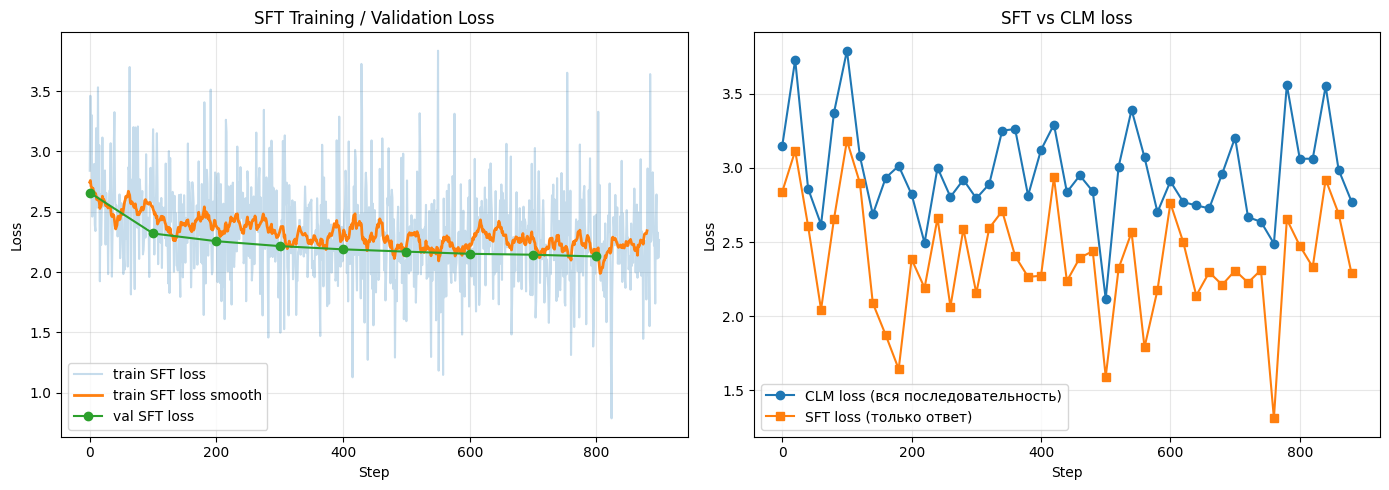

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(sft_losses, alpha=0.25, label="train SFT loss")
if len(sft_losses) >= 20:
    axes[0].plot(np.convolve(sft_losses, np.ones(20)/20, mode='valid'),
                 linewidth=2, label="train SFT loss smooth")
if val_losses:
    val_steps, val_vals = zip(*val_losses)
    axes[0].plot(val_steps, val_vals, 'o-', label="val SFT loss")
axes[0].set_xlabel("Step")
axes[0].set_ylabel("Loss")
axes[0].set_title("SFT Training / Validation Loss")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

clm_steps, clm_vals = zip(*clm_losses)
axes[1].plot(clm_steps, clm_vals, 'o-', label="CLM loss (вся последовательность)")
sft_at_clm_steps = [sft_losses[s] for s in clm_steps if s < len(sft_losses)]
axes[1].plot(list(clm_steps)[:len(sft_at_clm_steps)], sft_at_clm_steps, 's-', label="SFT loss (только ответ)")
axes[1].set_xlabel("Step")
axes[1].set_ylabel("Loss")
axes[1].set_title("SFT vs CLM loss")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


In [17]:
for user_msg in test_prompts[:3]:
    resp_base = generate_text(model, tokenizer, user_msg,
                              max_new_tokens=50)
    format_user_msg = format_chat(user_msg)[0]
    resp_sft = generate_text(sft_model, tokenizer, format_user_msg,
                             max_new_tokens=50)
    print(f"User: {user_msg}")
    print(f"Base: {resp_base[:150]}")
    print(f"SFT: {resp_sft[:150]}\n")

User: What is the capital of France?
Base: The French government has been in power since 1871. The country's economy grew by 2% between 1900 and 1920, but it was still a small nation with only 
SFT: The French Capital, which stands for "Capital City," refers to a city in Europe that has been established by European colonization. It was founded on 

User: Translate to French: Hello, how are you?
Base: The first thing I did was write a short story about the events of September 11th. It's called "A New Hope." The book is based on my own experiences as
SFT: I'm sorry for the delay. Please feel free and let me know if there's anything else that needs clarification or clarifying before we can begin our jour

User: Explain quantum computing in simple terms.
Base: The first step is to understand the nature of a system and how it works, which can be done by looking at its properties or using some other mathematic
SFT: Quantum computers are a type of computer that can be programmed to perform co

In [18]:
raw_prompt = "What is the capital of France?"
inputs_raw = tokenizer(raw_prompt, return_tensors="pt").to(device)
with torch.no_grad():
    out = sft_model.generate(**inputs_raw, max_new_tokens=30,
                         temperature=0.7, do_sample=True,
                         pad_token_id=tokenizer.eos_token_id)
raw_resp = tokenizer.decode(out[0][inputs_raw["input_ids"].shape[1]:],
                            skip_special_tokens=True)
print(f"Raw prompt: '{raw_prompt}'")
print(f"Ответ: {raw_resp[:120]}")
print()

formatted_resp = generate_text(sft_model, tokenizer, format_chat(raw_prompt)[0], max_new_tokens=30)
print(f"Formatted prompt: 'User: {raw_prompt}\\nAssistant: '")
print(f"Ответ: {formatted_resp[:120]}")

Raw prompt: 'What is the capital of France?'
Ответ: 

In France, the capital city is Paris. Its capital, Louis-Philippe, is known as the capital of this country.

Formatted prompt: 'User: What is the capital of France?\nAssistant: '
Ответ: The French Capital, which stands for "Capital City," refers to a city in Europe that has been established by European co


**Важно подчеркнуть, что SFT не увеличивает априорную информированность модели о мире.**

Изменяется не содержание знаний, а способ их использования: модель переобучается на новое распределение формата "запрос → ответ".

Это приводит к изменению условного распределения $P(y | x)$, не затрагивая фундаментально представления, сформированные на этапе предобучения.

## Reward model

In [19]:
pref_dataset = load_dataset(
    "trl-lib/ultrafeedback_binarized", split="train"
)
print(f"Preference примеров: {len(pref_dataset)}")

sample_pref = pref_dataset[0]
print(f"Колонки: {pref_dataset.column_names}")

README.md:   0%|          | 0.00/643 [00:00<?, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/131M [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/2.14M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/62135 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1000 [00:00<?, ? examples/s]

Preference примеров: 62135
Колонки: ['chosen', 'rejected', 'score_chosen', 'score_rejected']


In [20]:
def format_preference_pair(example):
    """
    Извлекаем prompt, chosen, rejected и форматируем в наш chat template.
    Берём последний user перед assistant; это лучше для multi-turn примеров.
    """
    chosen_messages = example["chosen"]
    rejected_messages = example["rejected"]

    prompt = ""
    chosen_response = ""
    rejected_response = ""

    for msg in chosen_messages:
        if msg["role"] == "user":
            prompt = msg["content"]
        elif msg["role"] == "assistant":
            chosen_response = msg["content"]
            break

    for msg in rejected_messages:
        if msg["role"] == "assistant":
            rejected_response = msg["content"]
            break

    if not prompt or not chosen_response or not rejected_response:
        return {
            "prompt": "",
            "prompt_text": "",
            "chosen_text": "",
            "rejected_text": "",
        }

    prompt_text, chosen_full = format_chat(prompt, chosen_response)
    _, rejected_full = format_chat(prompt, rejected_response)

    return {
        "prompt": normalize_text(prompt),
        "prompt_text": prompt_text,
        "chosen_text": chosen_full,
        "rejected_text": rejected_full,
    }


N_PREF_RAW = min(12000, len(pref_dataset))
pref_formatted = pref_dataset.select(range(N_PREF_RAW)).map(
    format_preference_pair,
    remove_columns=pref_dataset.column_names,
)
pref_formatted = pref_formatted.filter(lambda x: len(x["chosen_text"]) > 0)
print(f"Отформатированных пар: {len(pref_formatted)}")

print(f"\nПример prompt_text:\n  {repr(pref_formatted[0]['prompt_text'][:150])}")
print(f"\nПример chosen:\n  {repr(pref_formatted[0]['chosen_text'][:150])}")
print(f"\nПример rejected:\n  {repr(pref_formatted[0]['rejected_text'][:150])}")

Map:   0%|          | 0/12000 [00:00<?, ? examples/s]

Filter:   0%|          | 0/12000 [00:00<?, ? examples/s]

Отформатированных пар: 11979

Пример prompt_text:
  'User: Use the pygame library to write a version of the classic game Snake, with a unique twist\nAssistant:'

Пример chosen:
  "User: Use the pygame library to write a version of the classic game Snake, with a unique twist\nAssistant: Sure, I'd be happy to help you write a versi"

Пример rejected:
  "User: Use the pygame library to write a version of the classic game Snake, with a unique twist\nAssistant: Sure, here's an example of how to write a ve"


In [21]:
class GPT2RewardModel(torch.nn.Module):
    """
    GPT-2 backbone (замороженный) + линейная голова → скаляр.

    Это учебная RM, не полноценная production reward model. Чтобы сигнал был
    чуть стабильнее, берём mean pooling по непаддинговым токенам, а не только
    последний токен: для short/long ответов последний токен часто EOS.
    """
    def __init__(self, base_lm):
        super().__init__()
        self.backbone = copy.deepcopy(base_lm.transformer)
        hidden_size = base_lm.config.n_embd
        self.reward_head = torch.nn.Linear(hidden_size, 1)

        for param in self.backbone.parameters():
            param.requires_grad = False

    def forward(self, input_ids, attention_mask):
        outputs = self.backbone(
            input_ids=input_ids, attention_mask=attention_mask
        )
        hidden = outputs.last_hidden_state
        mask = attention_mask.unsqueeze(-1).float()
        pooled = (hidden * mask).sum(dim=1) / mask.sum(dim=1).clamp_min(1.0)
        return self.reward_head(pooled).squeeze(-1)


# RM обучаем поверх SFT-backbone, потому что именно SFT-модель потом сравниваем.
rm = GPT2RewardModel(sft_model).to(device)
n_trainable = sum(p.numel() for p in rm.parameters() if p.requires_grad)
print(f"\nRM: {n_trainable:,} обучаемых / "
      f"{sum(p.numel() for p in rm.parameters()):,} всего")


RM: 769 обучаемых / 124,440,577 всего


In [22]:
def tokenize_preference(examples):
    """
    Токенизация preference-пар для RM и DPO.

    Для DPO отбрасываем обрезанные пары: если chosen/rejected не помещается
    целиком, модель получает странный сигнал по неполному ответу без EOS.
    """
    chosen_features = [
        encode_response_only(prompt_text, chosen_text)
        for prompt_text, chosen_text in zip(examples["prompt_text"],
                                            examples["chosen_text"])
    ]
    rejected_features = [
        encode_response_only(prompt_text, rejected_text)
        for prompt_text, rejected_text in zip(examples["prompt_text"],
                                              examples["rejected_text"])
    ]

    return {
        "chosen_input_ids": [f["input_ids"] for f in chosen_features],
        "chosen_attention_mask": [f["attention_mask"] for f in chosen_features],
        "chosen_labels": [f["labels"] for f in chosen_features],
        "chosen_n_response_tokens": [f["n_response_tokens"] for f in chosen_features],
        "chosen_has_eos": [f["has_eos"] for f in chosen_features],
        "chosen_was_truncated": [f["was_truncated"] for f in chosen_features],
        "rejected_input_ids": [f["input_ids"] for f in rejected_features],
        "rejected_attention_mask": [f["attention_mask"] for f in rejected_features],
        "rejected_labels": [f["labels"] for f in rejected_features],
        "rejected_n_response_tokens": [f["n_response_tokens"] for f in rejected_features],
        "rejected_has_eos": [f["has_eos"] for f in rejected_features],
        "rejected_was_truncated": [f["was_truncated"] for f in rejected_features],
    }


pref_tokenized = pref_formatted.map(
    tokenize_preference, batched=True, batch_size=64,
    remove_columns=["prompt", "prompt_text", "chosen_text", "rejected_text"]
)

pref_tokenized = pref_tokenized.filter(
    lambda x: x["chosen_n_response_tokens"] >= 8 and
              x["rejected_n_response_tokens"] >= 8 and
              x["chosen_has_eos"] and x["rejected_has_eos"] and
              not x["chosen_was_truncated"] and
              not x["rejected_was_truncated"]
)
pref_tokenized.set_format("torch")
print(f"Токенизировано complete preference-пар: {len(pref_tokenized)}")

Map:   0%|          | 0/11979 [00:00<?, ? examples/s]

Filter:   0%|          | 0/11979 [00:00<?, ? examples/s]

Токенизировано complete preference-пар: 5934


In [23]:
def bradley_terry_loss(rm, batch):
    r_chosen = rm(
        batch["chosen_input_ids"].to(device),
        batch["chosen_attention_mask"].to(device)
    )
    r_rejected = rm(
        batch["rejected_input_ids"].to(device),
        batch["rejected_attention_mask"].to(device)
    )
    loss = -F.logsigmoid(r_chosen - r_rejected).mean()
    acc = (r_chosen > r_rejected).float().mean()
    return loss, acc


rm_loader = DataLoader(pref_tokenized, batch_size=16, shuffle=True)
rm_opt = torch.optim.AdamW(rm.reward_head.parameters(), lr=5e-4, weight_decay=0.01)

rm_losses, rm_accs = [], []
rm_steps = 200

rm.train()
step = 0
for batch in tqdm(rm_loader, total=rm_steps, desc="RM"):
    if step >= rm_steps:
        break
    loss, acc = bradley_terry_loss(rm, batch)
    rm_opt.zero_grad(set_to_none=True)
    loss.backward()
    rm_opt.step()
    rm_losses.append(loss.item())
    rm_accs.append(acc.item())
    if step % 50 == 0:
        print(f"  Step {step}: loss={loss.item():.4f}, acc={acc.item():.4f}")
    step += 1
rm.eval()

RM:   0%|          | 0/200 [00:00<?, ?it/s]

  Step 0: loss=0.7635, acc=0.1875
  Step 50: loss=0.6617, acc=0.6250
  Step 100: loss=0.7793, acc=0.1875
  Step 150: loss=0.6603, acc=0.6875


GPT2RewardModel(
  (backbone): GPT2Model(
    (wte): Embedding(50257, 768)
    (wpe): Embedding(1024, 768)
    (drop): Dropout(p=0.1, inplace=False)
    (h): ModuleList(
      (0-11): 12 x GPT2Block(
        (ln_1): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (attn): GPT2Attention(
          (c_attn): Conv1D(nf=2304, nx=768)
          (c_proj): Conv1D(nf=768, nx=768)
          (attn_dropout): Dropout(p=0.1, inplace=False)
          (resid_dropout): Dropout(p=0.1, inplace=False)
        )
        (ln_2): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (mlp): GPT2MLP(
          (c_fc): Conv1D(nf=3072, nx=768)
          (c_proj): Conv1D(nf=768, nx=3072)
          (act): NewGELUActivation()
          (dropout): Dropout(p=0.1, inplace=False)
        )
      )
    )
    (ln_f): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
  )
  (reward_head): Linear(in_features=768, out_features=1, bias=True)
)

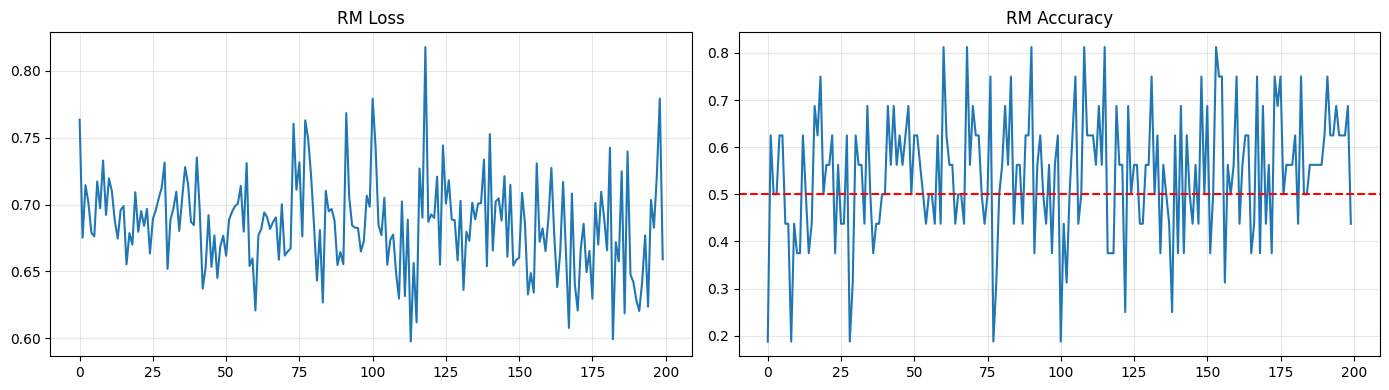

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(rm_losses); axes[0].set_title("RM Loss"); axes[0].grid(True, alpha=0.3)
axes[1].plot(rm_accs); axes[1].axhline(y=0.5, color='r', linestyle='--')
axes[1].set_title("RM Accuracy"); axes[1].grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

In [25]:
def score_response(rm, user_message, response, tokenizer, max_len=MAX_LEN):
    """Оценка ответа через учебную RM. Форматируем в тот же chat template."""
    _, full_text = format_chat(user_message, response)
    inputs = tokenizer(
        full_text, return_tensors="pt",
        truncation=True, max_length=max_len, padding="max_length"
    )
    with torch.no_grad():
        return rm(
            inputs["input_ids"].to(device),
            inputs["attention_mask"].to(device)
        ).item()


for user_msg in test_prompts[:3]:
    prompt, _ = format_chat(user_msg)
    resp_base = generate_text(model, tokenizer, prompt, max_new_tokens=50)
    resp_sft = generate_text(sft_model, tokenizer, prompt, max_new_tokens=50)

    s_base = score_response(rm, user_msg, resp_base, tokenizer)
    s_sft = score_response(rm, user_msg, resp_sft, tokenizer)

    print(f"User: {user_msg}")
    print(f"Base:  score={s_base:+.3f} | {resp_base[:100]}")
    print(f"SFT:   score={s_sft:+.3f} | {resp_sft[:100]}\n")

User: What is the capital of France?
Base:  score=-2.458 | The French are known for their great wealth and they have a very strong sense of justice. They belie
SFT:   score=-2.052 | The French Capital, which stands for "Capital City," refers to a city in Europe that has been establ

User: Translate to French: Hello, how are you?
Base:  score=-2.474 | I'm in France. You're welcome! Thank you for coming over here and taking a look at my work on the pr
SFT:   score=-2.721 | I'm sorry for the delay. Please feel free and let me know if there's anything else that needs clarif

User: Explain quantum computing in simple terms.
Base:  score=-2.469 | I'm not sure what you mean by "simple". It's a very complex concept, and it has many different uses 
SFT:   score=-1.658 | Quantum computers are a type of computer that can be programmed to perform computations on any physi



## Direct Preference Optimization

Несмотря на то, что SFT адаптирует модель к формату "инструкция → ответ", он не определяет механизм выбора между несколькими допустимыми ответами.

Для одного запроса x может существовать множество валидных ответов, различающихся по качеству. Поэтому вводится задача обучения на предпочтениях:

для пар $(y^+, y^-)$ должно выполняться:

$$ P(y^+ \mid x) > P(y^- \mid x). $$

Direct Preference Optimization (DPO) формализует обучение на предпочтениях без явного введения reward-модели.

Пусть $\pi_\theta$ &ndash; обучаемая модель, а $\pi_{ref}$ &ndash; фиксированная reference-модель (например, после SFT).

Оптимизация направлена на увеличение относительного преимущества предпочтительного ответа по сравнению с менее предпочтительным, с учётом базового распределения.

$$
L_{DPO} =
- \log \sigma \Big(
\beta \big[
(\log \pi_\theta(y^+ \mid x) - \log \pi_\theta(y^- \mid x))
-
(\log \pi_{ref}(y^+ \mid x) - \log \pi_{ref}(y^- \mid x))
\big]
\Big).
$$

Интерпретация:

- усиливается относительная вероятность предпочтительного ответа;
- одновременно вычитается вклад reference-модели, что стабилизирует обучение;
- параметр β контролирует "жёсткость" предпочтений.

In [26]:
def get_sequence_log_probs(model, input_ids, attention_mask, labels, average_log_prob=False):
    """
    log P(response | prompt) для каждого примера.

    labels=-100 для prompt/PAD. По умолчанию возвращаем сумму log-prob — это
    стандартно для DPO. average_log_prob=True полезен только для диагностики.
    """
    outputs = model(input_ids=input_ids, attention_mask=attention_mask)
    logits = outputs.logits

    # Causal LM предсказывает token[t] по logits[t-1].
    shift_logits = logits[:, :-1, :]
    shift_labels = labels[:, 1:]

    response_mask = (shift_labels != -100)
    safe_labels = shift_labels.masked_fill(~response_mask, 0)

    log_probs = F.log_softmax(shift_logits, dim=-1)
    token_log_probs = log_probs.gather(
        2, safe_labels.unsqueeze(-1)
    ).squeeze(-1)

    seq_log_probs = (token_log_probs * response_mask.float()).sum(dim=1)
    if average_log_prob:
        lengths = response_mask.float().sum(dim=1).clamp_min(1.0)
        seq_log_probs = seq_log_probs / lengths
    return seq_log_probs

In [27]:
def compute_dpo_loss(
    policy, reference,
    chosen_ids, chosen_mask, chosen_labels,
    rejected_ids, rejected_mask, rejected_labels,
    beta=0.05,
    average_log_prob=True
):
    """
    L = -mean[ log σ( β * (Δlog π_θ - Δlog π_ref) ) ]
    """
    pi_chosen = get_sequence_log_probs(
        policy, chosen_ids, chosen_mask, chosen_labels, average_log_prob=average_log_prob)
    pi_rejected = get_sequence_log_probs(
        policy, rejected_ids, rejected_mask, rejected_labels, average_log_prob=average_log_prob)

    with torch.no_grad():
        ref_chosen = get_sequence_log_probs(
            reference, chosen_ids, chosen_mask, chosen_labels, average_log_prob=average_log_prob)
        ref_rejected = get_sequence_log_probs(
            reference, rejected_ids, rejected_mask, rejected_labels, average_log_prob=average_log_prob)

    pi_logratios = pi_chosen - pi_rejected
    ref_logratios = ref_chosen - ref_rejected
    dpo_logits = beta * (pi_logratios - ref_logratios)

    loss = -F.logsigmoid(dpo_logits).mean()

    with torch.no_grad():
        implicit_r_chosen = beta * (pi_chosen - ref_chosen)
        implicit_r_rejected = beta * (pi_rejected - ref_rejected)
        acc = (dpo_logits > 0).float().mean()
        margin = dpo_logits.mean()

    return loss, acc.item(), implicit_r_chosen.mean().item(), \
        implicit_r_rejected.mean().item(), margin.item()

In [28]:
# Reference фиксируем как SFT-модель.
reference_model = copy.deepcopy(sft_model)
reference_model.eval()
for p in reference_model.parameters():
    p.requires_grad = False

# Policy — отдельная копия SFT. DPO не должен менять sft_model in-place.
policy_model = copy.deepcopy(sft_model)
policy_model.train()

dpo_loader = DataLoader(pref_tokenized, batch_size=2, shuffle=True)
dpo_opt = torch.optim.AdamW(policy_model.parameters(), lr=1e-6, weight_decay=0.01)

dpo_losses, dpo_accs = [], []
dpo_r_chosen, dpo_r_rejected, dpo_margins = [], [], []
dpo_steps = 300
beta = 0.05

step = 0
for batch in tqdm(dpo_loader, total=dpo_steps, desc="DPO"):
    if step >= dpo_steps:
        break

    loss, acc, rc, rr, margin = compute_dpo_loss(
        policy_model, reference_model,
        batch["chosen_input_ids"].to(device),
        batch["chosen_attention_mask"].to(device),
        batch["chosen_labels"].to(device),
        batch["rejected_input_ids"].to(device),
        batch["rejected_attention_mask"].to(device),
        batch["rejected_labels"].to(device),
        beta=beta,
    )

    dpo_opt.zero_grad(set_to_none=True)
    loss.backward()
    torch.nn.utils.clip_grad_norm_(policy_model.parameters(), 1.0)
    dpo_opt.step()

    dpo_losses.append(loss.item())
    dpo_accs.append(acc)
    dpo_r_chosen.append(rc)
    dpo_r_rejected.append(rr)
    dpo_margins.append(margin)

    if step % 50 == 0:
        print(f"  Step {step}: loss={loss.item():.4f}, acc={acc:.4f}, margin={margin:+.4f}")
    step += 1

policy_model.eval()

DPO:   0%|          | 0/300 [00:00<?, ?it/s]

  Step 0: loss=0.7037, acc=0.5000, margin=-0.0208
  Step 50: loss=0.6913, acc=1.0000, margin=+0.0036
  Step 100: loss=0.6937, acc=0.0000, margin=-0.0011
  Step 150: loss=0.6932, acc=0.5000, margin=-0.0002
  Step 200: loss=0.6932, acc=0.5000, margin=-0.0001
  Step 250: loss=0.6901, acc=1.0000, margin=+0.0061


GPT2LMHeadModel(
  (transformer): GPT2Model(
    (wte): Embedding(50257, 768)
    (wpe): Embedding(1024, 768)
    (drop): Dropout(p=0.1, inplace=False)
    (h): ModuleList(
      (0-11): 12 x GPT2Block(
        (ln_1): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (attn): GPT2Attention(
          (c_attn): Conv1D(nf=2304, nx=768)
          (c_proj): Conv1D(nf=768, nx=768)
          (attn_dropout): Dropout(p=0.1, inplace=False)
          (resid_dropout): Dropout(p=0.1, inplace=False)
        )
        (ln_2): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (mlp): GPT2MLP(
          (c_fc): Conv1D(nf=3072, nx=768)
          (c_proj): Conv1D(nf=768, nx=3072)
          (act): NewGELUActivation()
          (dropout): Dropout(p=0.1, inplace=False)
        )
      )
    )
    (ln_f): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
  )
  (lm_head): Linear(in_features=768, out_features=50257, bias=False)
)

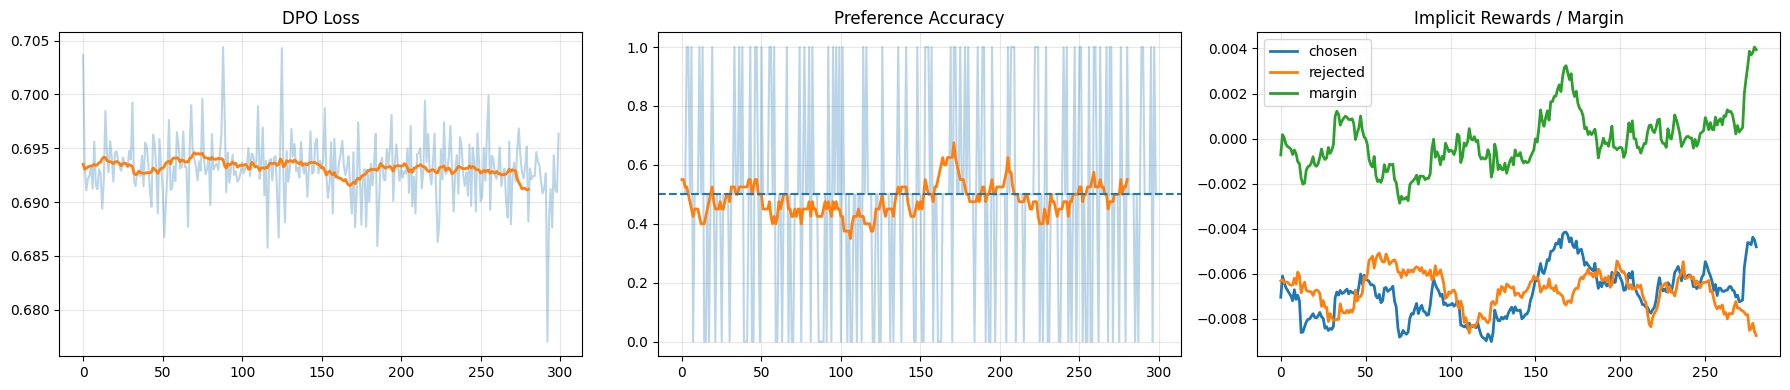

In [29]:
def smooth_curve(x, w=20):
    if len(x) < w:
        return np.asarray(x)
    return np.convolve(x, np.ones(w) / w, mode="valid")


fig, axes = plt.subplots(1, 3, figsize=(18, 4))

axes[0].plot(dpo_losses, alpha=0.3)
axes[0].plot(smooth_curve(dpo_losses), linewidth=2)
axes[0].set_title("DPO Loss"); axes[0].grid(True, alpha=0.3)

axes[1].plot(dpo_accs, alpha=0.3)
axes[1].plot(smooth_curve(dpo_accs), linewidth=2)
axes[1].axhline(y=0.5, linestyle="--")
axes[1].set_title("Preference Accuracy"); axes[1].grid(True, alpha=0.3)

axes[2].plot(smooth_curve(dpo_r_chosen), label="chosen", linewidth=2)
axes[2].plot(smooth_curve(dpo_r_rejected), label="rejected", linewidth=2)
axes[2].plot(smooth_curve(dpo_margins), label="margin", linewidth=2)
axes[2].set_title("Implicit Rewards / Margin"); axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

В результате оптимизации происходит перераспределение вероятностей в условном пространстве ответов:

- увеличивается вероятность $y^+$ относительно $y^-$;
- при этом сохраняется близость к $\pi_{ref}$, что предотвращает деградацию языкового качества.

Формально, происходит сдвиг распределения:

$$
\pi_\theta(y \mid x) \;\; \text{смещается в сторону предпочтительных ответов}
$$

Ключевая идея DPO заключается в том, что модель обучается не абсолютной оценке качества ответа, а сравнению пар ответов.

Таким образом, вместо задачи регрессии reward-функции решается задача прямой оптимизации вероятностного предпочтения.

## Итоговое сравнение и выводы

In [30]:
all_models = {
    "Base": model,
    "SFT": sft_model,
    "SFT+DPO": policy_model,
}

for user_msg in test_prompts:
    prompt, _ = format_chat(user_msg)
    print(f"\n{'='*70}")
    print(f"User: {user_msg}")
    print(f"{'='*70}")
    for name, m in all_models.items():
        resp = generate_text(m, tokenizer, prompt, max_new_tokens=80, min_new_tokens=12, do_sample=False)
        score = score_response(rm, user_msg, resp, tokenizer)
        print(f"\n  [{name}] (учебная RM score: {score:+.3f})")
        print(f"  {resp[:300]}")


User: What is the capital of France?

  [Base] (учебная RM score: -2.327)
  The French are known for their great wealth and they have a very strong sense of justice. They believe that if you don't do something right, then it will be punished by death or imprisonment in prison (in some cases). In other words…they think there's no way to get rid from this situation any more t

  [SFT] (учебная RM score: -2.052)
  The French Capital, which stands for "Capital City," refers to a city in Europe that has been established by European colonization. It was founded on land reclaimed from Spain and later acquired as part-of its territory during World War II.

  [SFT+DPO] (учебная RM score: -2.061)
  The French Capital, which stands for "Capital City," refers to a city in Europe that has been established by European colonization. It was originally named after Napoleon Bonaparte's famous poem about his conquest of Paris and its subsequent expansion into Spain during World War I.

User: Translate t

In [31]:
def compare_next_token(model_a, model_b, user_msg, name_a="SFT", name_b="SFT+DPO", top_k=10):
    """Сравниваем top-k next-token predictions в формате чата."""
    prompt, _ = format_chat(user_msg)
    inputs = tokenizer(prompt, return_tensors="pt").to(device)

    with torch.no_grad():
        logits_a = model_a(**inputs).logits[0, -1, :]
        logits_b = model_b(**inputs).logits[0, -1, :]

    probs_a = F.softmax(logits_a, dim=-1)
    probs_b = F.softmax(logits_b, dim=-1)

    all_top = set(
        torch.topk(probs_a, top_k).indices.tolist() +
        torch.topk(probs_b, top_k).indices.tolist()
    )

    token_data = [(t, probs_a[t].item(), probs_b[t].item()) for t in all_top]
    token_data.sort(key=lambda x: abs(x[2] - x[1]), reverse=True)

    print(f"\nUser: {user_msg}")
    print(f"  {'Token':<18} {name_a:<10} {name_b:<10} {'Δ':<10}")
    print("  " + "-" * 52)
    for t, pa, pb in token_data[:top_k]:
        token_str = tokenizer.decode([t]).replace("\xa0", "\\xa0")
        diff = pb - pa
        sign = "+" if diff > 0 else ""
        print(f"  {repr(token_str):<18} {pa:<10.4f} {pb:<10.4f} "
              f"{sign}{diff:<10.4f}")


compare_next_token(sft_model, policy_model,
                   "What is the capital of France?")
compare_next_token(sft_model, policy_model,
                   "Explain quantum computing in simple terms.")


User: What is the capital of France?
  Token              SFT        SFT+DPO    Δ         
  ----------------------------------------------------
  ' The'             0.6997     0.7063     +0.0066    
  ' France'          0.0576     0.0555     -0.0021   
  ' It'              0.0236     0.0216     -0.0020   
  ' Capital'         0.0344     0.0363     +0.0020    
  ' I'               0.0057     0.0040     -0.0017   
  ' In'              0.0218     0.0232     +0.0014    
  ' French'          0.0239     0.0253     +0.0014    
  ' To'              0.0114     0.0107     -0.0007   
  ' Paris'           0.0075     0.0070     -0.0005   
  ' First'           0.0085     0.0082     -0.0002   

User: Explain quantum computing in simple terms.
  Token              SFT        SFT+DPO    Δ         
  ----------------------------------------------------
  ' Quantum'         0.7751     0.7954     +0.0204    
  ' Let'             0.0102     0.0077     -0.0025   
  ' To'              0.0143     0.0127   

In [32]:
def estimate_policy_shift(policy, reference, dataloader, n_batches=20):
    """
    Это не настоящий KL. Это средний сдвиг log-prob на chosen-ответах:
    log πθ(y+|x) - log πref(y+|x).
    Отрицательное значение возможно и не является ошибкой.
    """
    values = []
    for i, batch in enumerate(dataloader):
        if i >= n_batches:
            break
        ids = batch["chosen_input_ids"].to(device)
        mask = batch["chosen_attention_mask"].to(device)
        labels = batch["chosen_labels"].to(device)
        with torch.no_grad():
            pi_lp = get_sequence_log_probs(policy, ids, mask, labels)
            ref_lp = get_sequence_log_probs(reference, ids, mask, labels)
        values.extend((pi_lp - ref_lp).cpu().tolist())
    return np.mean(values), np.std(values)


shift_m, shift_s = estimate_policy_shift(policy_model, reference_model, dpo_loader)
print(f"Mean log-prob shift on chosen responses: {shift_m:.4f} ± {shift_s:.4f}")

Mean log-prob shift on chosen responses: -0.1250 ± 1.0821


## Заключение

В семинаре был рассмотрен полный пайплайн обучения современных LLM: предобучение на задаче предсказания следующего токена и последующее выравнивание под человеческие предпочтения. Показано, что предобучение формирует базовые языковые и семантические представления, но не обеспечивает оптимального поведения модели без дополнительных этапов постобучения.

Методы RLHF и его упрощённые альтернативы (включая парное сравнение и DPO) позволяют согласовать генерацию с предпочтениями, однако критически зависят от качества данных и корректности построения reward-сигнала.

Итоговое качество модели определяется взаимодействием предобучения и этапов выравнивания, а также качеством разметки предпочтений.